# Exploratory data analysis

## Knowing data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
file=Path.cwd()
unemployment=pd.read_csv(file/'data'/'clean_unemployment.csv')
unemployment.head()

,country_code,country_name,continent,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,AFG,Afghanistan,Asia,11.35,11.05,11.34,11.19,11.14,11.13,11.16,11.18,11.15,11.22,11.71,13.28
1,AGO,Angola,Africa,9.43,7.36,7.35,7.37,7.37,7.39,7.41,7.41,7.42,7.42,8.33,8.53
2,ALB,Albania,Europe,14.09,13.48,13.38,15.87,18.05,17.19,15.42,13.62,12.30,11.47,13.33,11.82
3,ARE,United Arab Emirates,Asia,2.48,2.30,2.18,2.04,1.91,1.77,1.64,2.46,2.35,2.23,3.19,3.36
4,ARG,Argentina,South America,7.71,7.18,7.22,7.10,7.27,7.52,8.11,8.35,9.22,9.84,11.46,10.90


In [2]:
unemployment.info() # to check missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  182 non-null    object 
 1   country_name  182 non-null    object 
 2   continent     178 non-null    object 
 3   2010          182 non-null    float64
 4   2011          182 non-null    float64
 5   2012          182 non-null    float64
 6   2013          182 non-null    float64
 7   2014          182 non-null    float64
 8   2015          182 non-null    float64
 9   2016          182 non-null    float64
 10  2017          182 non-null    float64
 11  2018          182 non-null    float64
 12  2019          182 non-null    float64
 13  2020          182 non-null    float64
 14  2021          182 non-null    float64
dtypes: float64(12), object(3)
memory usage: 21.5+ KB


In [3]:
unemployment['continent']=unemployment['continent'].replace('Null', np.nan)
# count each category column
unemployment.value_counts('continent') # why only 177 values
# importing csv recognizes NaN and NA as missing values

continent
Africa           53
Asia             47
Europe           39
North America    18
South America    12
Oceania           8
Name: count, dtype: int64

In [4]:
unemployment['continent'].describe()

count        177
unique         6
top       Africa
freq          53
Name: continent, dtype: object

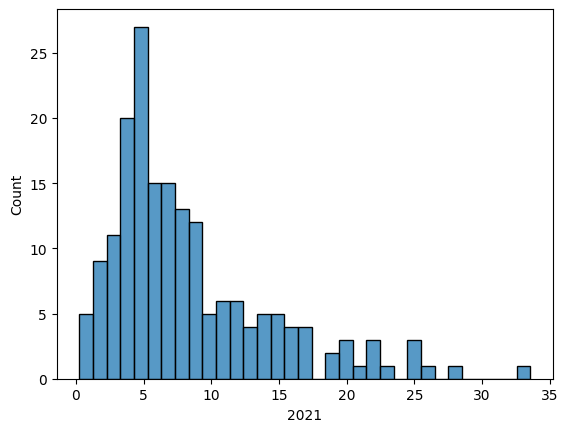

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
# distribution of unemployment in all countries
sns.histplot(data=unemployment, x='2021', binwidth=1)
plt.show()

## data validation

In [6]:
# checking data types
unemployment['continent']=unemployment['continent'].astype(str)
unemployment.dtypes.head(2)

country_code    object
country_name    object
dtype: object

In [7]:
# checking set values `isin()`
not_oceania = ~unemployment["continent"].isin(["Oceania"])
unemployment[not_oceania].head(2)

,country_code,country_name,continent,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,AFG,Afghanistan,Asia,11.35,11.05,11.34,11.19,11.14,11.13,11.16,11.18,11.15,11.22,11.71,13.28
1,AGO,Angola,Africa,9.43,7.36,7.35,7.37,7.37,7.39,7.41,7.41,7.42,7.42,8.33,8.53


0.26 33.56


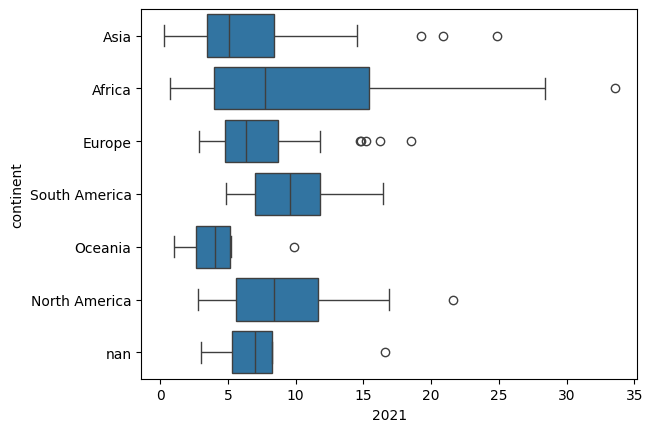

In [8]:
# checking ranges using boxplot
print(unemployment['2021'].min(), unemployment['2021'].max())

sns.boxplot(data=unemployment, x='2021', y='continent')
plt.show()

## summarization

- `.groupby()`: working with category variables
- `.sum()`, `.count()`, `.mean()` etc: aggregating functions
- `.agg()`: to apply multiple aggregating function
    - use dict:  `{'column_name': ['mean', 'median'], ...}`
    - use tuple: `new_var_name=('column_name', 'mean')`

> customized function for pandas

In [9]:
unemployment[['country_name',"continent", "2019", "2020"]].groupby(['country_name','continent']).agg(['mean', 'std']).head(2)

2019       2020    
                         mean std   mean std
country_name continent                      
Afghanistan  Asia       11.22 NaN  11.71 NaN
Albania      Europe     11.47 NaN  13.33 NaN

In [10]:
print(unemployment[["continent", "2019", "2020"]].groupby("continent").agg(['mean', 'std']))
continent_summary = unemployment.groupby("continent").agg(
    # Create the mean_rate_2021 column
    mean_rate_2021=('2021', 'mean'),
    # Create the std_rate_2021 column
    std_rate_2021=('2021','std')
)
print(continent_summary)

                   2019                 2020          
                   mean       std       mean       std
continent                                             
Africa         9.264340  7.455293  10.307736  7.928166
Asia           5.949149  5.254008   7.012340  5.699609
Europe         6.764359  4.124734   7.470513  4.071218
North America  7.095000  4.770490   9.297778  4.963045
Oceania        3.773750  2.369068   4.273750  2.617490
South America  7.719167  3.379845  10.275000  3.411263
nan            6.680000  5.246275   8.104000  5.182584
               mean_rate_2021  std_rate_2021
continent                                   
Africa              10.473585       8.131636
Asia                 6.906170       5.414745
Europe               7.414872       3.947825
North America        9.155000       5.076482
Oceania              4.280000       2.671522
South America        9.924167       3.611624
nan                  8.030000       5.163240


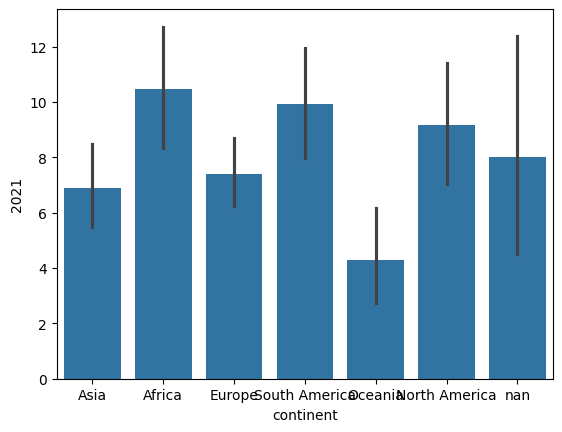

In [11]:
sns.barplot(data=unemployment,x='continent',y='2021')
plt.show()

## missing data

Handling them:
- dropping
- imputing by summary stats
- imputing by group stats

In [12]:
from pathlib import Path
file=Path.cwd()
planes=pd.read_csv(file/'data'/'planes.csv')
planes.info()
print(len(planes))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10660 entries, 0 to 10659
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          10233 non-null  object 
 1   Date_of_Journey  10338 non-null  object 
 2   Source           10473 non-null  object 
 3   Destination      10313 non-null  object 
 4   Route            10404 non-null  object 
 5   Dep_Time         10400 non-null  object 
 6   Arrival_Time     10466 non-null  object 
 7   Duration         10446 non-null  object 
 8   Total_Stops      10448 non-null  object 
 9   Additional_Info  10071 non-null  object 
 10  Price            10044 non-null  float64
dtypes: float64(1), object(10)
memory usage: 916.2+ KB
10660


In [13]:
planes['Source'].isna().sum()
planes.isna().sum()

Airline            427
Date_of_Journey    322
Source             187
Destination        347
Route              256
Dep_Time           260
Arrival_Time       194
Duration           214
Total_Stops        212
Additional_Info    589
Price              616
dtype: int64

In [14]:
# return the column indices
planes.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [15]:
# Filter the DataFrame for object columns
non_numeric = planes.select_dtypes("object")
# Loop through columns
for i in non_numeric.columns:
  # Print the number of unique values
  print(f"Number of unique values in {i} column: ", non_numeric[i].nunique())

Number of unique values in Airline column:  8
Number of unique values in Date_of_Journey column:  44
Number of unique values in Source column:  5
Number of unique values in Destination column:  6
Number of unique values in Route column:  126
Number of unique values in Dep_Time column:  221
Number of unique values in Arrival_Time column:  1334
Number of unique values in Duration column:  367
Number of unique values in Total_Stops column:  5
Number of unique values in Additional_Info column:  10


### dropping rows with NaN

In [16]:
# Find the five percent threshold
threshold = len(planes) * 0.05

# Create a filter
cols_to_drop = planes.columns[planes.isna().sum() <= threshold]

# Drop missing values for columns below the threshold
planes.dropna(subset=cols_to_drop, inplace=True)

print(planes.isna().sum())

Airline              0
Date_of_Journey      0
Source               0
Destination          0
Route                0
Dep_Time             0
Arrival_Time         0
Duration             0
Total_Stops          0
Additional_Info    300
Price              368
dtype: int64


### dropping columns

In [17]:
# Check the values of the Additional_Info column 
print(planes["Additional_Info"].value_counts())

# no useful info so I can drop
planes.drop(columns=["Additional_Info"], inplace=True)

# or planes2=planes.drop(columns=['Additional_Info'])

Additional_Info
No info                         6399
In-flight meal not included     1525
No check-in baggage included     258
1 Long layover                    14
Change airports                    7
No Info                            2
Business class                     1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64


### imputing Nan by groups

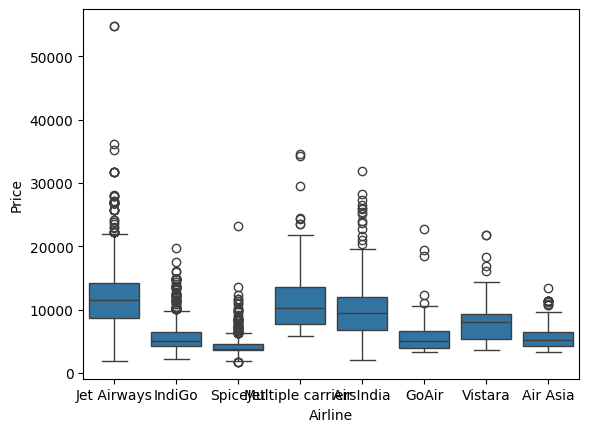

In [18]:
# Create a box plot of Price by Airline
sns.boxplot(data=planes, x='Airline',y='Price', )
plt.show()

# impute using group stats
# Calculate median plane ticket prices by Airline
airline_prices = planes.groupby("Airline")["Price"].median()

prices_dict = airline_prices.to_dict()

# Map the dictionary to missing values of Price by Airline
planes["Price"] = planes["Price"].fillna(planes["Airline"].map(prices_dict))

# rename the price
planes.rename(columns={'Price':'cleaned_price'}, inplace=True)

> `.fillna()` aligns by index labels (row labels). In this case both Series share the same index, so it’s effectively row-by-row.

> `.rename(columns={'old_name':'new_name'},inplace=True)` to change column label

## create categories

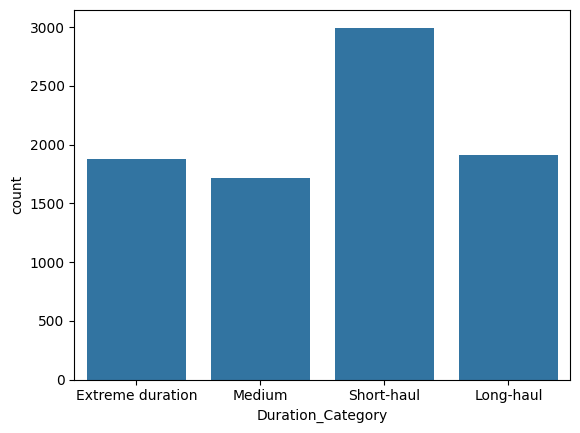

In [19]:
# 3 cases and conditions
short_flights = "^0h|^1h|^2h|^3h|^4h"
medium_flights = "^5h|^6h|^7h|^8h|^9h"
long_flights = "^10h|^11h|^12h|^13h|^14h|^15h|^16h"

conditions = [
    (planes["Duration"].str.contains(short_flights)),
    (planes["Duration"].str.contains(medium_flights)),
    (planes["Duration"].str.contains(long_flights))
]

# categories
categories = ["Short-haul", "Medium", "Long-haul"]

# case_when python way
planes["Duration_Category"] = np.select(conditions, 
                                        categories,
                                        default="Extreme duration")

# Plot the counts of each category
sns.countplot(data=planes, x="Duration_Category")
plt.show()

> `^9h`: start with 9h but `9h`: contains 9h -> 9h or 19h or 29h

## create summary stats column

using `.transform()`

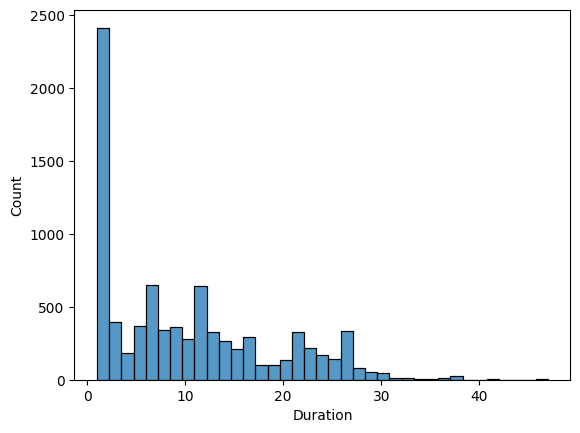

In [20]:
# Remove the string character
planes["Duration"] = planes["Duration"].str.replace("h", "")
planes["Duration"] = planes["Duration"].str.replace(r'\s.*', '', regex=True)
# Convert to float data type
planes.loc[planes["Duration"]=='5m', "Duration"]=np.nan

planes["Duration"] = planes["Duration"].astype(float)

# Plot a histogram
sns.histplot(data=planes, x='Duration')
plt.show()

> alternative using iloc for numpy array without index
```
mask = (planes["Duration"] == "5m").to_numpy()
col = planes.columns.get_loc("Duration")   # or just put the integer col index you want
planes.iloc[mask, col] = np.nan
```

In [21]:
planes["airline_median_duration"] = planes.groupby("Airline")["Duration"].transform(lambda x: x.median())

print(planes[["Airline","airline_median_duration"]].value_counts())

Airline            airline_median_duration
Jet Airways        13.0                       3082
IndiGo             2.0                        1632
Air India          15.0                       1399
Multiple carriers  10.0                        959
SpiceJet           2.0                         653
Vistara            3.0                         376
Air Asia           2.0                         260
GoAir              2.0                         147
Name: count, dtype: int64


In [22]:
# Find the 75th and 25th percentiles
price_seventy_fifth = planes["cleaned_price"].quantile(0.75)
price_twenty_fifth = planes["cleaned_price"].quantile(0.25)

# Calculate iqr
prices_iqr = price_seventy_fifth - price_twenty_fifth

# Calculate the thresholds
upper = price_seventy_fifth + (1.5 * prices_iqr)
lower = price_twenty_fifth - (1.5 * prices_iqr)

# Subset the data
planes = planes[(planes["cleaned_price"] > lower) & (planes["cleaned_price"] < upper)]

print(planes["cleaned_price"].describe())

count     8438.000000
mean      8877.466046
std       4001.838236
min       1759.000000
25%       5224.000000
50%       8372.000000
75%      12121.000000
max      22270.000000
Name: cleaned_price, dtype: float64
